In [1]:
import sys
print(sys.executable)
print(sys.version)

/home/suzunyan/.venv/bin/python
3.12.11 (main, Aug 15 2025, 13:38:57) [GCC 8.5.0 20210514 (Red Hat 8.5.0-28)]


Let's open the ROOT file from CERN's eos partition into a pandas DataFrame now

In [2]:
import matplotlib.pyplot as plt
import uproot
import numpy as np
import awkward as ak
import pandas as pd
import particle
from tqdm import tqdm

In [3]:
#corrected path/ file 
#for opening ROOT file from CERN's eos partition into a pandas DataFrame
path = "/lstr/sahara/niueftracking/kesedlac/muon_isolation/OUTPUT/run_InvPtPU200/"
input_file = uproot.open(path + 'OutputIsolation.root:OutputIsolation')
df = ak.to_dataframe(input_file.arrays(library="ak"))

Let's see what the data column key names are 

In [4]:
df.keys()

Index(['Truth_InDetTrack_pdg_ID', 'InDetTrack_pt', 'InDetTrack_eta',
       'InDetTrack_phi', 'InDetTrack_d0', 'InDetTrack_z0sinTheta',
       'InDetTrack_z0', 'InDetTrack_vx', 'InDetTrack_vy', 'InDetTrack_vz',
       'hasTruthLink', 'isMuon'],
      dtype='object')

In [7]:
f = uproot.open(path + 'OutputIsolation.root:OutputIsolation')
print(f.keys())  # see ALL available branches

['Truth_InDetTrack_pdg_ID', 'InDetTrack_pt', 'InDetTrack_eta', 'InDetTrack_phi', 'InDetTrack_d0', 'InDetTrack_z0sinTheta', 'InDetTrack_z0', 'InDetTrack_vx', 'InDetTrack_vy', 'InDetTrack_vz', 'hasTruthLink', 'isMuon']


Testing for truth type.

In [5]:
event_df = df.xs(0, level="entry")
muon_vz = event_df.loc[event_df['hasTruthLink'], 'InDetTrack_vz'].values[0]
all_vz = event_df['InDetTrack_vz'].values
print(f"Muon vz: {muon_vz:.4f}")
print(f"All tracks vz: mean={all_vz.mean():.4f}, std={all_vz.std():.4f}")
print(f"Unique vz values: {len(np.unique(np.round(all_vz, 3)))}")

Muon vz: 19.2528
All tracks vz: mean=0.0123, std=0.4868
Unique vz values: 2


There are two different types here:
- there is `Truth_InDetTrack_pdg_ID`, which contain the PDG ID of actual truth tracks
- those starting with `InDetTrack`, which contain the kinematic variables of all inner detector tracks with or without a link to a valid truth particle (the information for that is saved to `hasTruthLink`

Do you understand what the names refer to? They probably are a bit cryptic, but see if you can make sense of some and then we should talk about this.

This dataframe now contains two indices: one for enumerating entries or events from our simulation and one to index the entries within one event (for multiple tracks e.g.)

In [5]:
indices_list = df.index
print(indices_list)

MultiIndex([(   0,    0),
            (   0,    1),
            (   0,    2),
            (   0,    3),
            (   0,    4),
            (   0,    5),
            (   0,    6),
            (   0,    7),
            (   0,    8),
            (   0,    9),
            ...
            (9999, 1954),
            (9999, 1955),
            (9999, 1956),
            (9999, 1957),
            (9999, 1958),
            (9999, 1959),
            (9999, 1960),
            (9999, 1961),
            (9999, 1962),
            (9999, 1963)],
           names=['entry', 'subentry'], length=19024383)


In [6]:
df.xs(0, level="entry")

,Truth_InDetTrack_pdg_ID,InDetTrack_pt,InDetTrack_eta,InDetTrack_phi,InDetTrack_d0,InDetTrack_z0sinTheta,InDetTrack_z0,InDetTrack_vx,InDetTrack_vy,InDetTrack_vz,hasTruthLink,isMuon
subentry,,,,,,,,,,,,
0,0,943.039151,-2.041082,1.882903,-0.009580,12.321689,48.232140,0.0,0.0,0.0,False,False
1,0,1130.486690,2.030765,0.433432,-0.042191,-8.671330,-33.606388,0.0,0.0,0.0,False,False
2,0,2246.514533,2.703746,-1.572634,-0.034050,-9.055980,-67.931274,0.0,0.0,0.0,False,False
3,0,609.229181,-2.887901,-1.178189,-0.231472,9.059484,81.586411,0.0,0.0,0.0,False,False
4,0,3068.442810,1.813480,0.101507,-0.014447,10.835480,34.103760,0.0,0.0,0.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1558,0,641.573044,3.040227,-0.321104,-0.373497,-7.983694,-83.660378,0.0,0.0,0.0,False,False
1559,0,1418.547726,2.938055,1.851817,1.273534,-0.711932,-6.739166,0.0,0.0,0.0,False,False
1560,0,782.564547,3.132373,0.769284,-0.251261,3.749425,43.065781,0.0,0.0,0.0,False,False


Let's check, what shapes the different columns have:

In [7]:
for key in df.keys():
    print(f"Column {key} has size {len(df[key][0].index)}")

print(f"Number of truth muons: {np.sum(abs(df['Truth_InDetTrack_pdg_ID'][0]) == 13)}")

Column Truth_InDetTrack_pdg_ID has size 1563
Column InDetTrack_pt has size 1563
Column InDetTrack_eta has size 1563
Column InDetTrack_phi has size 1563
Column InDetTrack_d0 has size 1563
Column InDetTrack_z0sinTheta has size 1563
Column InDetTrack_z0 has size 1563
Column InDetTrack_vx has size 1563
Column InDetTrack_vy has size 1563
Column InDetTrack_vz has size 1563
Column hasTruthLink has size 1563
Column isMuon has size 1563
Number of truth muons: 1


Here we are looking at the first "event" which is represented by index `0` in the DataFrame.
This event contains one true muon track (which makes sense for the simulation setup used here, which is simulating a single muon in a pile-up environment), and

In [8]:
print(len(df['InDetTrack_pt'][0].index))

1563


track in total.

In this sample, only one true track should exist: the simulated muon. So let's see how many events have more than one muon:

In [9]:
#setting up unique events index
event_indices = df.index.get_level_values(0).unique()[:9999] #change events number here

two_muon_events = []
for event in event_indices:
    if np.sum(df['hasTruthLink'][event]) > 1:
        two_muon_events.append(True)
    else:
        two_muon_events.append(False)

two_muon_events = np.array(two_muon_events)

#making sure lengths match
doubled_events = event_indices[two_muon_events]
print(doubled_events)

Index([1404, 7066, 8659], dtype='int64', name='entry')


In [10]:
df.loc[doubled_events]

Truth_InDetTrack_pdg_ID  InDetTrack_pt  InDetTrack_eta  \
entry subentry                                                           
1404  0                               0    1141.558060       -1.855233   
      1                               0    1116.248895        1.782204   
      2                               0    1016.885132       -2.553845   
      3                               0    1320.473742       -2.547562   
      4                               0    1691.837742        2.771246   
...                                 ...            ...             ...   
8659  1975                            0     831.405062        2.186927   
      1976                            0    1809.049497        3.001477   
      1977                            0     532.738693       -2.629384   
      1978                            0    1775.422740        0.216319   
      1979                            0     969.807580       -1.023195   

                InDetTrack_phi  InDetTrack_d0  InDetTrack_z0sinTheta  \
entry subentry                                                         
1404  0               3.114831       0.087427              -3.480577   
      1              -1.594698      -0.062385              16.719694   
      2              -1.220608      -0.042163               5.817791   
      3               2.566306      -0.072329              -2.584072   
      4              -0.179939      -0.036321              -3.144298   
...                        ...            ...                    ...   
8659  1975           -1.054582       0.646122              31.834545   
      1976           -0.863257       2.156378               2.448429   
      1977           -2.532300       7.729087              -5.209198   
      1978           -2.802368      -0.165507             -40.629131   
      1979            1.611991      -0.056828              55.760975   

                InDetTrack_z0  InDetTrack_vx  InDetTrack_vy  InDetTrack_vz  \
entry subentry                                                               
1404  0            -11.398197            0.0            0.0            0.0   
      1             51.088757            0.0            0.0            0.0   
      2             37.624310            0.0            0.0            0.0   
      3            -16.608072            0.0            0.0            0.0   
      4            -25.219023            0.0            0.0            0.0   
...                       ...            ...            ...            ...   
8659  1975         143.574692            0.0            0.0            0.0   
      1976          24.686203            0.0            0.0            0.0   
      1977         -36.301208            0.0            0.0            0.0   
      1978         -41.583439            0.0            0.0            0.0   
      1979          87.586914            0.0            0.0            0.0   

                hasTruthLink  isMuon  
entry subentry                        
1404  0                False   False  
      1                False   False  
      2                False   False  
      3                False   False  
      4                False   False  
...                      ...     ...  
8659  1975             False   False  
      1976             False   False  
      1977             False   False  
      1978             False   False  
      1979             False   False  

[5461 rows x 12 columns]

So here there are 

In [11]:
print(len(doubled_events))

3


such events. Let's remove those events completely for now. For this we invert the boolean mask we just created, and cast it to a pandas series (which essentially just makes it the right format for dataframes)

In [12]:
one_muon_events = pd.Series(np.invert(two_muon_events), name='bools')

In [13]:
#define indices_list as all tuples (event, track) in dataframe
indices_list = df.index

#counts number of events before we remove the >1 muon events
events_before = len(np.unique(indices_list.get_level_values(0)))

#removes all doubled events from list
df_clean = df.drop(doubled_events, level='entry')

#updates df 
df = df_clean

How many events (indexed by the data frame's index) are there in this file? Let'S get the event indices to count:

In [14]:
#counts number of events after removing doubled muon events
events_after = len(np.unique(df_clean.index.get_level_values(0)))

In [15]:
# prints the number of events before and after filtering
print(f"There were {events_before} events in this file")
print(f"There are now {events_after} events in this field")
print(f"There were {events_before - events_after} problematic events removed")

There were 10000 events in this file
There are now 9997 events in this field
There were 3 problematic events removed


Now let's check what particles created the tracks we're looking at here. The `particle` package provides nice utilities to convert the integer PDG ID to a human readable name.

Let's find an event now with a track associated to a truth particle for this:

In [16]:
event_indices = np.unique(indices_list.get_level_values(0))
for event in event_indices:
    if np.sum(df.xs(event, level="entry")['hasTruthLink']) > 0:
        truth_event_df = df.xs(event, level="entry")
        break

for p in truth_event_df.index:
    if truth_event_df['hasTruthLink'][p]:
        pdg = truth_event_df['Truth_InDetTrack_pdg_ID'][p]
        print(f"Truth particle in event {p} with PDG ID {pdg} is {particle.Particle.from_pdgid(pdg)}")

Truth particle in event 8 with PDG ID 13 is mu-


Let's look at that event's data

In [17]:
truth_event_df

,Truth_InDetTrack_pdg_ID,InDetTrack_pt,InDetTrack_eta,InDetTrack_phi,InDetTrack_d0,InDetTrack_z0sinTheta,InDetTrack_z0,InDetTrack_vx,InDetTrack_vy,InDetTrack_vz,hasTruthLink,isMuon
subentry,,,,,,,,,,,,
0,0,943.039151,-2.041082,1.882903,-0.009580,12.321689,48.232140,0.0,0.0,0.0,False,False
1,0,1130.486690,2.030765,0.433432,-0.042191,-8.671330,-33.606388,0.0,0.0,0.0,False,False
2,0,2246.514533,2.703746,-1.572634,-0.034050,-9.055980,-67.931274,0.0,0.0,0.0,False,False
3,0,609.229181,-2.887901,-1.178189,-0.231472,9.059484,81.586411,0.0,0.0,0.0,False,False
4,0,3068.442810,1.813480,0.101507,-0.014447,10.835480,34.103760,0.0,0.0,0.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1558,0,641.573044,3.040227,-0.321104,-0.373497,-7.983694,-83.660378,0.0,0.0,0.0,False,False
1559,0,1418.547726,2.938055,1.851817,1.273534,-0.711932,-6.739166,0.0,0.0,0.0,False,False
1560,0,782.564547,3.132373,0.769284,-0.251261,3.749425,43.065781,0.0,0.0,0.0,False,False


Now try to create some histograms of these variables (for all or at least a larger number of events)

# Single muon events in pile-up

In [18]:
indices_list = df.index
print(f"First 20 entries of indices_list:\n {indices_list[:20]}")

First 20 entries of indices_list:
 MultiIndex([(0,  0),
            (0,  1),
            (0,  2),
            (0,  3),
            (0,  4),
            (0,  5),
            (0,  6),
            (0,  7),
            (0,  8),
            (0,  9),
            (0, 10),
            (0, 11),
            (0, 12),
            (0, 13),
            (0, 14),
            (0, 15),
            (0, 16),
            (0, 17),
            (0, 18),
            (0, 19)],
           names=['entry', 'subentry'])


Here we should find more tracks alongside the single muon that we simulated.

Let's check, what shapes the different columns have:

In [19]:
for key in df.keys():
    print(f"Column {key} has size {len(df[key][0].index)}")
print(f"Number of truth muons: {np.sum(abs(df['Truth_InDetTrack_pdg_ID'][0]) == 13)}")

Column Truth_InDetTrack_pdg_ID has size 1563
Column InDetTrack_pt has size 1563
Column InDetTrack_eta has size 1563
Column InDetTrack_phi has size 1563
Column InDetTrack_d0 has size 1563
Column InDetTrack_z0sinTheta has size 1563
Column InDetTrack_z0 has size 1563
Column InDetTrack_vx has size 1563
Column InDetTrack_vy has size 1563
Column InDetTrack_vz has size 1563
Column hasTruthLink has size 1563
Column isMuon has size 1563
Number of truth muons: 1


Here we are looking at the first "event" which is represented by index `0` in the DataFrame.
This event contains one true muon track (which makes sense for the simulation setup used here, which is simulating a single muon in a pile-up environment), and

In [20]:
print(len(df['InDetTrack_pt'][0].index)-1)

1562


other tracks.
From the way we simulated this, we know that these other tracks are pile-up tracks.

In this sample, only one true track should exist: the simulated muon. So let's see how many events have more than one muon:

In [21]:
for ind in tqdm(indices_list[:80000]):
    if np.sum(abs(df['Truth_InDetTrack_pdg_ID'][ind[0]]) == 13) > 1:
        print(df.iloc[ind[0]])

100%|██████████| 80000/80000 [00:17<00:00, 4491.26it/s]


How many events (indexed by the data frame's index) are there in this file?

In [22]:
event_indices = np.unique(indices_list.get_level_values(0))

In [23]:
print(f"There are {len(event_indices)} events in this file")

There are 9997 events in this file


Now let's check what particles created the tracks we're looking at here. The `particle` package provides nice utilities to convert the integer PDG ID to a human readable name.

Let's find an event now with a track associated to a truth particle for this:

In [24]:
index = 0
event = indices_list[index]
print(event)

(0, 0)


In [25]:
event = indices_list[index+1]

while not df['hasTruthLink'][event]:
    index += 1
    event = indices_list[index]
    print(event)
    

for p in df['Truth_InDetTrack_pdg_ID'][event[0]][df['hasTruthLink'][event[0]]]:
    print(f"Truth particle in event {event[0]}, track number {event[1]} with PDG ID {p} is {particle.Particle.from_pdgid(p)}")

(0, 1)
(0, 2)
(0, 3)
(0, 4)
(0, 5)
(0, 6)
(0, 7)
(0, 8)
Truth particle in event 0, track number 8 with PDG ID 13 is mu-


Let's look at that track's data

In [26]:
event


(0, 8)

In [27]:
df.loc(0)

In [28]:
print(df.loc[event[0]])

          Truth_InDetTrack_pdg_ID  InDetTrack_pt  InDetTrack_eta  \
subentry                                                           
0                               0     943.039151       -2.041082   
1                               0    1130.486690        2.030765   
2                               0    2246.514533        2.703746   
3                               0     609.229181       -2.887901   
4                               0    3068.442810        1.813480   
...                           ...            ...             ...   
1558                            0     641.573044        3.040227   
1559                            0    1418.547726        2.938055   
1560                            0     782.564547        3.132373   
1561                            0    6222.434663        2.680823   
1562                            0    3952.089823        2.788110   

          InDetTrack_phi  InDetTrack_d0  InDetTrack_z0sinTheta  InDetTrack_z0  \
subentry                          

And the whole event (with it's unreadable number of entries):

In [29]:
df.loc[999,1]


Truth_InDetTrack_pdg_ID              0
InDetTrack_pt              1999.113028
InDetTrack_eta               -2.034737
InDetTrack_phi                0.658064
InDetTrack_d0                 0.133286
InDetTrack_z0sinTheta        11.342682
InDetTrack_z0                44.128448
InDetTrack_vx                      0.0
InDetTrack_vy                      0.0
InDetTrack_vz                      0.0
hasTruthLink                     False
isMuon                           False
Name: (999, 1), dtype: object

Now to create some histograms of these variables for that exact event:

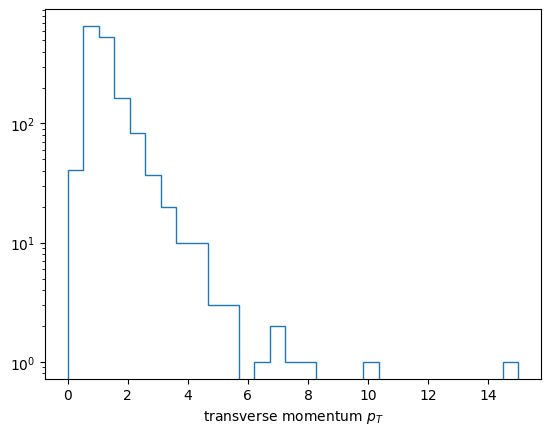

In [30]:
plt.hist(df.loc[event[0]]['InDetTrack_pt'] / 1000, bins=np.linspace(0, 15, 30), histtype='step')
plt.xlabel(r"transverse momentum $p_T$")
plt.yscale('log')

Text(0.5, 0, 'eta$')

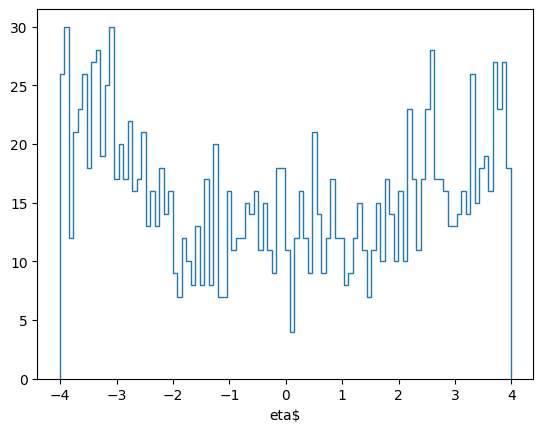

In [31]:
plt.hist(df.loc[event[0]]['InDetTrack_eta'], bins=100, histtype='step')
plt.xlabel(r"eta$")

Text(0.5, 0, 'phi $\\phi$')

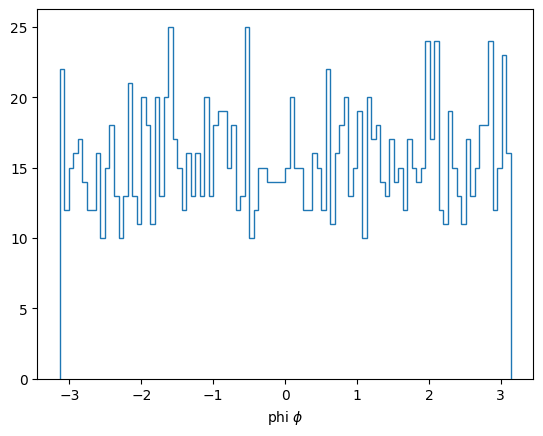

In [32]:
plt.hist(df.loc[event[0]]['InDetTrack_phi'], bins=100, histtype='step')
plt.xlabel(r"phi $\phi$")

Text(0.5, 0, 'd0')

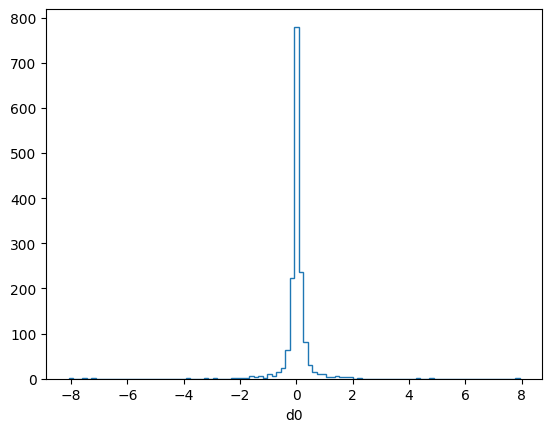

In [33]:
plt.hist(df.loc[event[0]]['InDetTrack_d0'], bins=100, histtype='step')
plt.xlabel(r"d0")

Text(0.5, 0, 'z0')

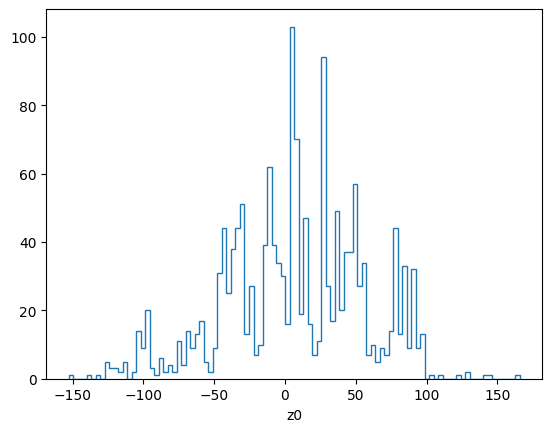

In [34]:
plt.hist(df.loc[event[0]]['InDetTrack_z0'], bins=100, histtype='step')
plt.xlabel(r"z0")

Text(0.5, 0, 'vertex x')

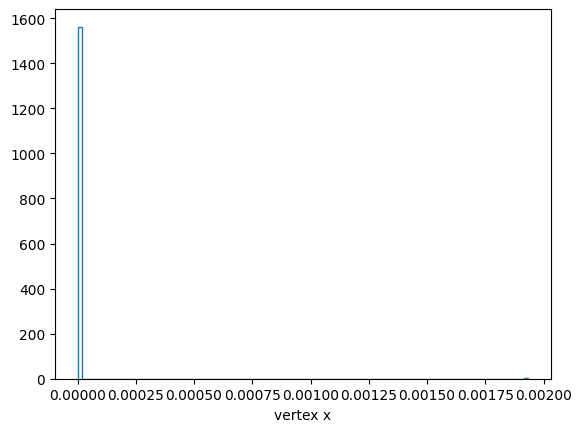

In [35]:
plt.hist(df.loc[event[0]]['InDetTrack_vx'], bins=100, histtype='step')
plt.xlabel(r"vertex x")

Text(0.5, 0, 'vertex y')

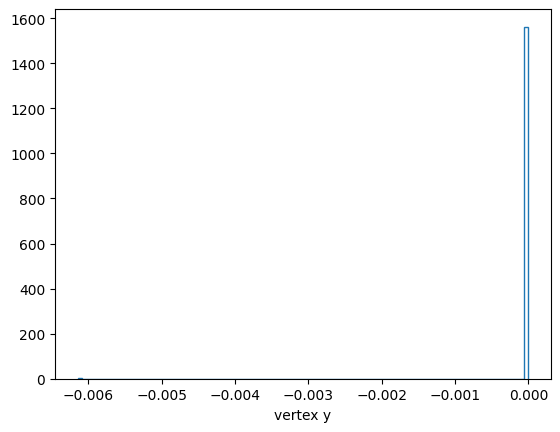

In [36]:
plt.hist(df.loc[event[0]]['InDetTrack_vy'], bins=100, histtype='step')
plt.xlabel(r"vertex y")

Text(0.5, 0, 'vertex z')

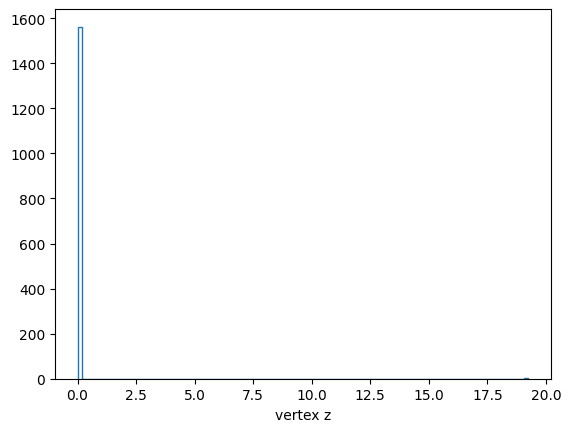

In [37]:
plt.hist(df.loc[event[0]]['InDetTrack_vz'], bins=100, histtype='step')
plt.xlabel(r"vertex z")

Text(0.5, 0, 'pt')

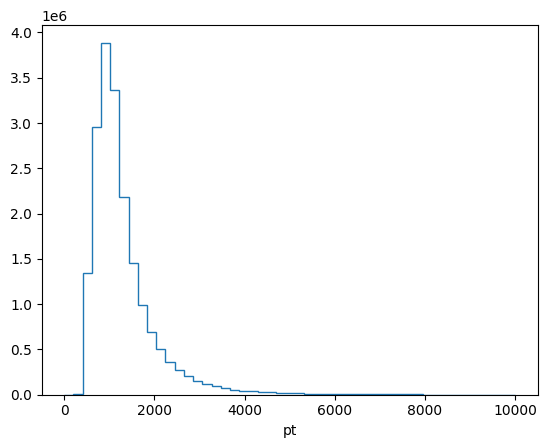

In [38]:
_, bins_vec, _ = plt.hist(df['InDetTrack_pt'],bins = np.linspace(0,10000) , histtype='step')
#plt.hist(df['InDetTrack_eta']/2., bins=bins_vec, histtype='step')

plt.xlabel("pt")

Text(0.5, 0, '$\\eta$')

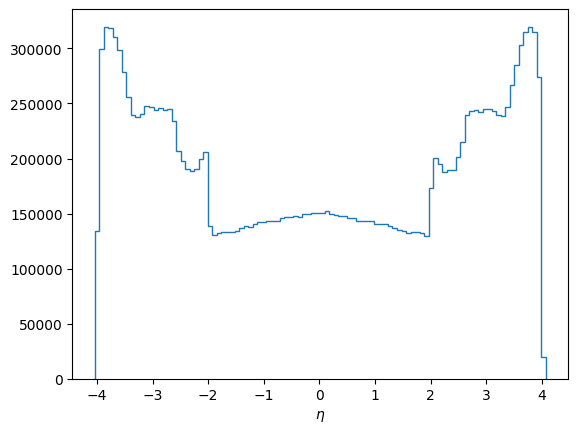

In [39]:
_, bins_vec, _ = plt.hist(df['InDetTrack_eta'], bins=100, histtype='step')
#plt.hist(df['InDetTrack_eta']/2., bins=bins_vec, histtype='step')
plt.xlabel(r"$\eta$")


Text(0.5, 0, '$\\phi$')

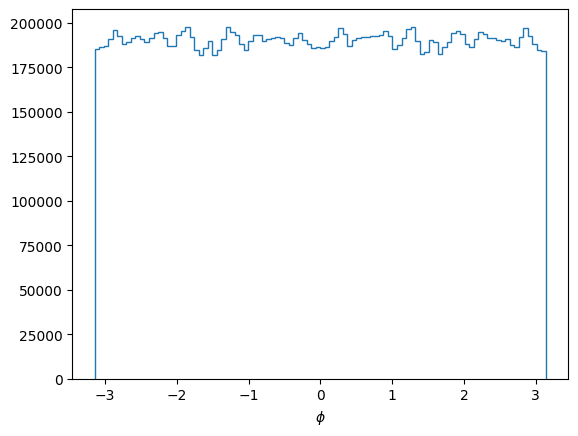

In [40]:
_, bins_vec, _ = plt.hist(df['InDetTrack_phi'], bins=100, histtype='step')
#plt.hist(df['InDetTrack_eta']/2., bins=bins_vec, histtype='step')
plt.xlabel(r"$\phi$")

Text(0.5, 0, 'd0')

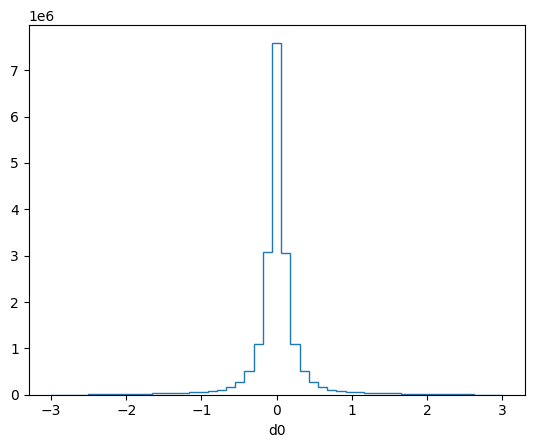

In [41]:
_, bins_vec, _ = plt.hist(df['InDetTrack_d0'], bins = np.linspace(-3,3), histtype='step')
#plt.hist(df['InDetTrack_eta']/2., bins=bins_vec, histtype='step')
plt.xlabel("d0")

Text(0.5, 0, 'z0')

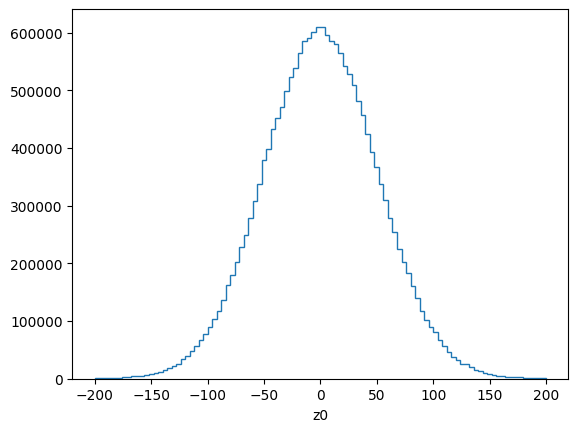

In [42]:
_, bins_vec, _ = plt.hist(df['InDetTrack_z0'], bins=100, histtype='step')
#plt.hist(df['InDetTrack_eta']/2., bins=bins_vec, histtype='step')
plt.xlabel("z0")

Text(0.5, 0, 'vx')

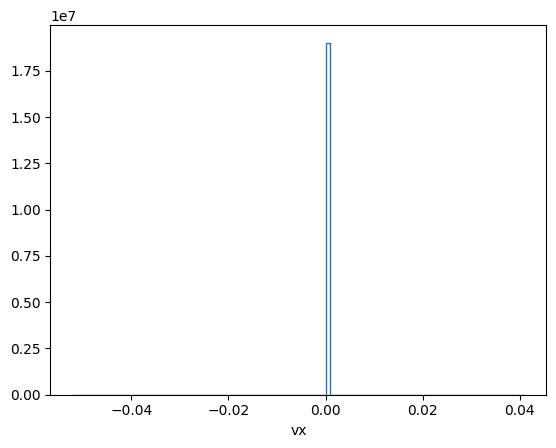

In [43]:
_, bins_vec, _ = plt.hist(df['InDetTrack_vx'], bins=100, histtype='step')
#plt.hist(df['InDetTrack_eta']/2., bins=bins_vec, histtype='step')
plt.xlabel("vx")

Text(0.5, 0, 'vy')

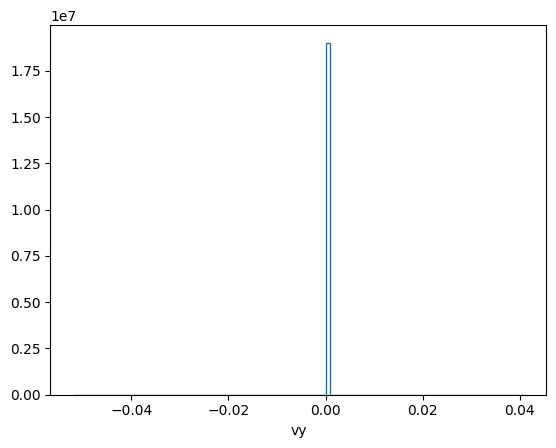

In [44]:
_, bins_vec, _ = plt.hist(df['InDetTrack_vx'], bins=100, histtype='step')
#plt.hist(df['InDetTrack_eta']/2., bins=bins_vec, histtype='step')
plt.xlabel("vy")

In [45]:
rows, cols = df.shape
print(rows)
print(cols)

19018922
12


Text(0.5, 0, 'vz')

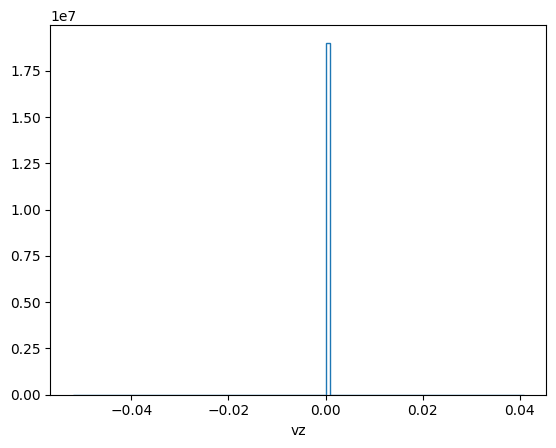

In [46]:
_, bins_vec, _ = plt.hist(df['InDetTrack_vx'], bins=100, histtype='step')
#plt.hist(df['InDetTrack_eta']/2., bins=bins_vec, histtype='step')
plt.xlabel("vz")

In [47]:
#systematic sampling method

def get_systematic_sample(df, n_events):
    all_events = df.index.get_level_values(0).unique()
    total_events = len(all_events)
    
    #calculate sampling interval
    k = total_events // n_events
    
    #take every k-th event
    event_indices = all_events[::k][:n_events]
    
    return event_indices

#usage for deltaRs
n_events = 500
event_indices = get_systematic_sample(df, n_events)

#deltaR calculation code goes here
deltaRs = []
for event in tqdm(event_indices):
    event_df = df.xs(event, level="entry")
    mask = event_df['hasTruthLink']
    if np.sum(mask) != 1:
        continue

#     try:
#         muon_eta = df.loc[event]['InDetTrack_eta'][mask].values[0]
#         muon_phi = df.loc[event]['InDetTrack_phi'][mask].values[0]
#     except IndexError:
    muon_eta = df.loc[event]['InDetTrack_eta'][mask].values
    muon_phi = df.loc[event]['InDetTrack_phi'][mask].values
    for track in event_df[np.invert(mask)].index:
        deltaphi = abs(event_df.loc[track]['InDetTrack_phi'] - muon_phi)
        if deltaphi > np.pi:
            deltaphi = 2*np.pi - deltaphi
        deltaeta = abs(event_df.loc[track]['InDetTrack_eta'] - muon_eta)
        deltaRs.append(np.sqrt(deltaphi**2 + deltaeta**2))

100%|██████████| 500/500 [01:21<00:00,  6.16it/s]


In [ ]:
# random sampling method
# the random_state is for setting the random seed
def get_random_sample(df, n_events, random_state=42):
    all_events = df.index.get_level_values(0).unique()
    return np.random.choice(all_events, size=n_events, replace=False)

# Usage
n_events = 500
event_indices = get_random_sample(df, n_events)

#deltaR calculation code goes here
deltaRs = []
for event in tqdm(event_indices):
    event_df = df.xs(event, level="entry")
    mask = event_df['hasTruthLink']
    if np.sum(mask) != 1:
        continue

#     try:
#         muon_eta = df.loc[event]['InDetTrack_eta'][mask].values[0]
#         muon_phi = df.loc[event]['InDetTrack_phi'][mask].values[0]
#     except IndexError:
    muon_eta = df.loc[event]['InDetTrack_eta'][mask].values
    muon_phi = df.loc[event]['InDetTrack_phi'][mask].values
    for track in event_df[np.invert(mask)].index:
        deltaphi = abs(event_df.loc[track]['InDetTrack_phi'] - muon_phi)
        if deltaphi > np.pi:
            deltaphi = 2*np.pi - deltaphi
        deltaeta = abs(event_df.loc[track]['InDetTrack_eta'] - muon_eta)
        deltaRs.append(np.sqrt(deltaphi**2 + deltaeta**2))

In [48]:
#prints number of calculated deltaRs
print(f"Number of deltaR values: {len(deltaRs):,}")

Number of deltaR values: 891,273


In [1]:
#pltting deltaRs using numpy

counts, bins = np.histogram(deltaRs, bins=100)
plt.step(bins[:-1], counts, where='post')
plt.xlabel(r"$\Delta R$")
plt.ylabel("Count")
plt.show()

NameError: name 'np' is not defined